In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from match3.game.level import Level, Objective, ObjectiveType
from match3.players.random_player import RandomPlayer
from match3.simulation.simulator import simulate_games

%matplotlib inline

In [19]:
GOAL_RANGE = np.arange(3,52)
MOVE_BUDGET = 20
NUM_GAMES = 100

In [20]:
rng = np.random.default_rng(42)
player = RandomPlayer(rng)

In [ ]:
results_dict = {}

for goal in GOAL_RANGE:
    level = Level(
        name=f"Collect {goal} Red Candies",
        moves=MOVE_BUDGET,
        objective=Objective(
            type=ObjectiveType.COLLECT,
            target=int(goal),
            candy_type=0,
        ),
    )

    rng = np.random.default_rng(42 + int(goal))
    player = RandomPlayer(rng)

    results = simulate_games(
        level,
        player,
        n_games=NUM_GAMES,
        rng=rng,
    )

    win_rate = np.mean([result.won for result in results])
    results_dict[int(goal)] = win_rate

In [ ]:
win_df = pd.DataFrame.from_dict(results_dict, orient="index", columns=["win_rate"])

Text(0, 0.5, 'Win Rate')

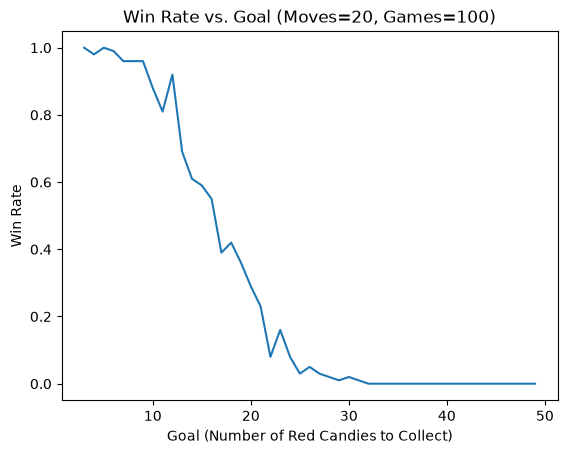

In [ ]:
plt.plot(list(results_dict.keys()), list(results_dict.values()))
plt.title(f"Win Rate vs. Goal (Moves={MOVE_BUDGET}, Games={NUM_GAMES})")
plt.xlabel("Goal (Number of Red Candies to Collect)")
plt.ylabel("Win Rate")